# Tuần 5 — bảng tổng hợp nộp mentor

> **Chạy notebook này SAU CÙNG**, sau `01`, `02`, `03`, `04`. Nó chỉ đọc lại kết quả đã lưu trong
> `ket_qua/` chứ không tính lại gì.

> **Mentor:** *"Các em không cần làm lại các bảng phân tích của tuần 4. Chỉ cần dùng kết quả hiện
> tại làm baseline và bổ sung một bảng ngắn so sánh các phương án mới. Bảng này cần trả lời rõ hai
> câu hỏi: kết quả ở nhóm chuyến dài và giá cao có thực sự tốt hơn không, và kết quả chung bị ảnh
> hưởng thế nào."*

Notebook này sinh ra đúng **một bảng** đó, cộng hai hình.

## Nguyên tắc đọc bảng

Mỗi hàng là một phương án. Trên cùng một hàng có cả **cái nhận được** (cột nhóm hiếm) và **cái phải
trả** (cột toàn tập) — để không ai đọc riêng một nửa.

Nhóm cố định theo **giá thật** và **quãng đường**, giống nhau cho mọi phương án.

In [1]:
import warnings, time, sys, json
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
EVAL = Path("../model/evaluation")
DATA = Path("../data/hcm_train_ready.parquet")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
KQ   = Path("ket_qua"); KQ.mkdir(exist_ok=True)

In [2]:
# ══ NHÓM CỐ ĐỊNH — quy tắc chốt cho cả tuần 5 ══════════════════════════
# Mentor tuần 4: "giữ nguyên nhóm chuyến giữa các model. Không nên để mỗi model
# tự chia nhóm theo giá mà chính nó dự đoán."
# => nhóm chia theo GIÁ THẬT và QUÃNG ĐƯỜNG, hai thứ không phụ thuộc model nào.
CAT_GIA = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN_GIA = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]
CAT_KM  = [0, 2, 5, 8, 12, 15, np.inf]
TEN_KM  = ["<2", "2–5", "5–8", "8–12", "12–15", ">15"]

def gan_nhom(d, cot_gia="y", cot_km="km"):
    d = d.copy()
    d["band"] = pd.cut(d[cot_gia], CAT_GIA, labels=TEN_GIA)
    d["kmb"]  = pd.cut(d[cot_km],  CAT_KM,  labels=TEN_KM)
    return d

def mape(p, y):
    p, y = np.asarray(p, float), np.asarray(y, float)
    return float(np.mean(np.abs(p - y) / y))

def boot_hieu(p_moc, p_moi, y, B=2000, seed=7):
    """CI 95% cho (sai số mốc − sai số mới). Dương = phương án mới TỐT HƠN."""
    y = np.asarray(y, float)
    h = np.abs(np.asarray(p_moc, float) - y)/y - np.abs(np.asarray(p_moi, float) - y)/y
    if len(h) < 2:
        return float("nan"), float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    mau = rng.integers(0, len(h), size=(B, len(h)))
    pp = h[mau].mean(axis=1)
    return h.mean(), float(np.percentile(pp, 2.5)), float(np.percentile(pp, 97.5))

def bang_theo_nhom(d, cot_moc, cot_moi, ten_moc="mốc", ten_moi="mới"):
    """MAPE hai phương án trên từng nhóm cố định + CI của chênh lệch."""
    hang = []
    for cot_nhom, nhan in [("kmb", "km"), ("band", "giá thật")]:
        for g, s in d.groupby(cot_nhom, observed=True):
            if len(s) < 30:
                continue
            m, lo, hi = boot_hieu(s[cot_moc], s[cot_moi], s.y)
            hang.append({"Chia theo": nhan, "Nhóm": str(g), "n": len(s),
                         ten_moc: mape(s[cot_moc], s.y), ten_moi: mape(s[cot_moi], s.y),
                         "Chênh (điểm)": m*100, "CI thấp": lo*100, "CI cao": hi*100,
                         "Khác 0": "✔" if (lo > 0 or hi < 0) else ""})
    m, lo, hi = boot_hieu(d[cot_moc], d[cot_moi], d.y)
    hang.append({"Chia theo": "—", "Nhóm": "TOÀN TẬP", "n": len(d),
                 ten_moc: mape(d[cot_moc], d.y), ten_moi: mape(d[cot_moi], d.y),
                 "Chênh (điểm)": m*100, "CI thấp": lo*100, "CI cao": hi*100,
                 "Khác 0": "✔" if (lo > 0 or hi < 0) else ""})
    return pd.DataFrame(hang)

def in_bang(df, cot_mape):
    return df.style.format({**{c: "{:.2%}" for c in cot_mape},
                            "Chênh (điểm)": "{:+.2f}", "CI thấp": "{:+.2f}",
                            "CI cao": "{:+.2f}", "n": "{:,}"}).hide(axis="index")

In [3]:
# ══ Nạp dự đoán đã có: Hybrid (mốc) và GAM ═════════════════════════════
ut  = pd.read_parquet(EVAL / "uq_pred_test.parquet").reset_index(drop=True)
gam = pd.read_parquet(EVAL / "pred_gam.parquet").reset_index(drop=True)
assert len(ut) == len(gam) and np.allclose(ut.gia_that.values, gam.gia_that.values), \
    "Hai file không cùng thứ tự hàng — không ghép được"

D = pd.DataFrame({
    "thang":  ut.evaluation_month.values,
    "lag":    ut.requested_lag_minutes.values,
    "km":     ut.quote_distance.values,
    "gio":    ut.gio_vn.values,
    "y":      ut.gia_that.values,
    "hybrid": ut.hybrid_pred.values,
    "gam":    gam.hybrid_pred.values,
    "pers":   ut.persistence.values,
})
D = gan_nhom(D[D.lag == 5].reset_index(drop=True))
print(f"Test lag 5 phút: {len(D):,} chuyến · {D.thang.nunique()} tháng")
print(f"MAPE mốc Hybrid {mape(D.hybrid, D.y):.2%} · GAM {mape(D.gam, D.y):.2%}")

Test lag 5 phút: 216,090 chuyến · 3 tháng
MAPE mốc Hybrid 14.65% · GAM 14.89%


## 1. Nạp kết quả từ các notebook trước

In [4]:
def doc_json(ten):
    f = KQ / ten
    if not f.exists():
        print(f"  ✘ thiếu {ten} — chưa chạy notebook tương ứng")
        return None
    print(f"  ✔ {ten}")
    return json.load(open(f, encoding="utf-8"))

print("Kết quả có sẵn:")
A  = doc_json("A_cau_hinh.json")       # 01 trong so  — che do NHANH
W  = doc_json("W_cau_hinh.json")       # HUONG_1      — luoi trong so day du
B1 = doc_json("B1_ket_luan.json")      # 02 on dinh
B2 = doc_json("B2_cau_hinh.json")      # 03 ghep
C1 = doc_json("C1_ket_luan.json")      # 04 mondrian

# ══ Nguon so cho hang "trong so" ═══════════════════════════════════════
# HUONG_1 chay che do day du (48 luot train) nhung chi luu BANG, khong luu mang
# du doan. Nguoc lai 01_TRONG_SO luu mang du doan nhung chay che do NHANH.
# => uu tien bang day du; chi lui ve A_pred_tot.npy khi thieu bang.
f_wkm, f_wgia, f_wchinh = (KQ / "W_bang_theo_km.csv", KQ / "W_bang_theo_gia.csv",
                           KQ / "W_bang_chinh.csv")
DUNG_W = (W is not None and not W.get("nhanh", True)
          and all(f.exists() for f in (f_wkm, f_wgia, f_wchinh)))
if DUNG_W:
    WKM    = pd.read_csv(f_wkm)
    WGIA   = pd.read_csv(f_wgia)
    WCHINH = pd.read_csv(f_wchinh)
    print(f"  → hàng trọng số lấy từ HUONG_1 — chế độ đầy đủ, "
          f"{len(W['cach_gan'])} cách gán × {len(W['trong_so'])} mức trọng số")

f_pred = KQ / "A_pred_tot.npy"
PRED_A = np.load(f_pred) if f_pred.exists() else None
if PRED_A is not None and len(PRED_A) != len(D):
    print(f"  ⚠ A_pred_tot.npy có {len(PRED_A):,} dòng, D có {len(D):,} — bỏ qua")
    PRED_A = None
if DUNG_W and PRED_A is not None:
    print("  → bỏ qua A_pred_tot.npy (chế độ nhanh) vì đã có bảng đầy đủ")

Kết quả có sẵn:
  ✔ A_cau_hinh.json
  ✔ W_cau_hinh.json
  ✔ B1_ket_luan.json
  ✔ B2_cau_hinh.json
  ✔ C1_ket_luan.json
  → hàng trọng số lấy từ HUONG_1 — chế độ đầy đủ, 3 cách gán × 6 mức trọng số
  → bỏ qua A_pred_tot.npy (chế độ nhanh) vì đã có bảng đầy đủ


## 2. Bảng D4 — bảng nộp mentor

Ba nhóm quan tâm, chọn theo đúng câu hỏi của tuần: chuyến dài, chuyến giá cao, và toàn tập.

In [5]:
NHOM_D4 = [("kmb", ">15", "Chuyến >15 km"),
           ("kmb", "12–15", "Chuyến 12–15 km"),
           ("band", ">300k", "Giá thật >300k")]
MOC = mape(D.hybrid, D.y)

def mot_hang(ten_pa, pred, ghi_chu=""):
    r = {"Phương án": ten_pa}
    for cn, g, nhan in NHOM_D4:
        s = D[D[cn].astype(str) == g]
        r[nhan] = mape(pred[s.index.values], s.y.values)
    r["Toàn tập"] = mape(pred, D.y.values)
    r["Δ toàn tập"] = (r["Toàn tập"] - MOC) * 100
    r["Ghi chú"] = ghi_chu
    return r

# Hai cau hinh trong so duoc trich vao bao cao tuan 5:
#   gan theo GIA w=10         — phuong an duy nhat keo duoc nhom >300k xuong
#   gan theo QUANG DUONG w=20 — muc manh nhat cua cach gan nham vao >15 km
PA_W = [("Hiếm = chuyến >300k",  10, "Trọng số theo giá w=10"),
        ("Hiếm = chuyến >15 km", 20, "Trọng số theo quãng đường w=20")]

def hang_tu_bang(cach, w, ten):
    """Doc MAPE tu bang HUONG_1 — khong co mang du doan nen khong tinh lai duoc."""
    k = WKM[(WKM["Cách gán"] == cach) & (WKM.w == w)].iloc[0]
    g = WGIA[(WGIA["Cách gán"] == cach) & (WGIA.w == w)].iloc[0]
    return {"Phương án": ten,
            "Chuyến >15 km": k[">15"], "Chuyến 12–15 km": k["12–15"],
            "Giá thật >300k": g[">300k"], "Toàn tập": k["TOÀN TẬP"],
            "Δ toàn tập": (k["TOÀN TẬP"] - MOC) * 100,
            "Ghi chú": "chỉ train lại nhánh giá cơ bản · chế độ đầy đủ"}

hang = [mot_hang("Hybrid GBM (mốc)", D.hybrid.values, "baseline tuần 4"),
        mot_hang("GAM đơn lẻ", D.gam.values, "kém hơn trên toàn tập")]

if DUNG_W:
    hang += [hang_tu_bang(c, w, t) for c, w, t in PA_W]
elif PRED_A is not None:
    hang.append(mot_hang(f"Trọng số {A['cach']} w={A['w']}", PRED_A,
                         "chỉ train lại nhánh giá cơ bản"
                         + (" · CHẾ ĐỘ NHANH" if A.get("nhanh") else "")))

if B2 is not None:
    # dung lai ham tron de tinh tren TOAN BO D (bao gom ca thang do tham so)
    a = np.clip((D.km.values - B2["d0"]) / max(B2["d1"] - B2["d0"], 1e-9), 0, 1) * B2["amax"]
    pred_ghep = (1 - a) * D.hybrid.values + a * D.gam.values
    hang.append(mot_hang(f"Ghép GAM–GBM (d₀={B2['d0']:.0f}, d₁={B2['d1']:.0f})",
                         pred_ghep, f"tham số dò trên {B2['thang_do']}"))

D4 = pd.DataFrame(hang)
COT_MAPE = [x[2] for x in NHOM_D4] + ["Toàn tập"]
D4.style.format({**{c: "{:.2%}" for c in COT_MAPE}, "Δ toàn tập": "{:+.3f}"}) \
        .hide(axis="index")

Phương án,Chuyến >15 km,Chuyến 12–15 km,Giá thật >300k,Toàn tập,Δ toàn tập,Ghi chú
Hybrid GBM (mốc),17.52%,15.26%,23.67%,14.65%,+0.000,baseline tuần 4
GAM đơn lẻ,15.37%,14.91%,22.03%,14.89%,+0.238,kém hơn trên toàn tập
Trọng số theo giá w=10,21.69%,18.23%,20.44%,14.71%,+0.063,chỉ train lại nhánh giá cơ bản · chế độ đầy đủ
Trọng số theo quãng đường w=20,18.51%,15.56%,23.53%,14.66%,+0.009,chỉ train lại nhánh giá cơ bản · chế độ đầy đủ
"Ghép GAM–GBM (d₀=6, d₁=14)",15.40%,14.92%,22.24%,14.64%,-0.011,tham số dò trên 2026-01


### Khoảng tin cậy

Bảng MAPE trần trụi không đủ để kết luận, nhất là ở nhóm `>15 km` chỉ có vài trăm chuyến. Bảng dưới
đây cho chênh lệch so với mốc kèm CI 95%.

In [6]:
def ket_luan(lo, hi):
    return "tốt hơn" if lo > 0 else "tệ hơn" if hi < 0 else "không phân biệt"

N_NHOM = {nhan: len(D[D[cn].astype(str) == g]) for cn, g, nhan in NHOM_D4}
N_NHOM["Toàn tập"] = len(D)

# Cot CI tuong ung trong W_bang_chinh.csv — HUONG_1 da bootstrap san.
COT_W = [("Chuyến >15 km",  "Δ >15 km",   "CI thấp (km)",    "CI cao (km)"),
         ("Giá thật >300k", "Δ >300k",    "CI thấp (300k)",  "CI cao (300k)"),
         ("Toàn tập",       "Δ toàn tập", "CI thấp (chung)", "CI cao (chung)")]

hang = []
for _, r in D4.iterrows():
    ten = r["Phương án"]
    if ten.startswith("Hybrid"):
        continue

    if ten.startswith("Trọng số") and DUNG_W:
        # Khong co mang du doan cho che do day du -> dung CI da bootstrap san.
        # Nhom 12–15 km khong co trong W_bang_chinh nen vang mat o bang nay.
        cach, w, _ = next(x for x in PA_W if x[2] == ten)
        s = WCHINH[(WCHINH["Cách gán"] == cach) & (WCHINH.w == w)].iloc[0]
        for nhan, c_d, c_lo, c_hi in COT_W:
            hang.append({"Phương án": ten, "Nhóm": nhan, "n": N_NHOM[nhan],
                         "Chênh (điểm)": s[c_d], "CI thấp": s[c_lo], "CI cao": s[c_hi],
                         "Kết luận": ket_luan(s[c_lo], s[c_hi])})
        continue

    if ten.startswith("GAM"):
        pred = D.gam.values
    elif ten.startswith("Trọng số"):
        pred = PRED_A
    else:
        pred = pred_ghep
    for cn, g, nhan in NHOM_D4:
        s = D[D[cn].astype(str) == g]
        m, lo, hi = boot_hieu(s.hybrid.values, pred[s.index.values], s.y.values)
        hang.append({"Phương án": ten, "Nhóm": nhan, "n": len(s),
                     "Chênh (điểm)": m*100, "CI thấp": lo*100, "CI cao": hi*100,
                     "Kết luận": ket_luan(lo, hi)})
    m, lo, hi = boot_hieu(D.hybrid.values, pred, D.y.values)
    hang.append({"Phương án": ten, "Nhóm": "Toàn tập", "n": len(D),
                 "Chênh (điểm)": m*100, "CI thấp": lo*100, "CI cao": hi*100,
                 "Kết luận": ket_luan(lo, hi)})

CI = pd.DataFrame(hang)
CI.style.format({"Chênh (điểm)": "{:+.2f}", "CI thấp": "{:+.2f}",
                 "CI cao": "{:+.2f}", "n": "{:,}"}).hide(axis="index")

Phương án,Nhóm,n,Chênh (điểm),CI thấp,CI cao,Kết luận
GAM đơn lẻ,Chuyến >15 km,660,+2.16,+1.36,+2.91,tốt hơn
GAM đơn lẻ,Chuyến 12–15 km,"2,045",+0.35,+0.15,+0.56,tốt hơn
GAM đơn lẻ,Giá thật >300k,869,+1.65,+1.17,+2.12,tốt hơn
GAM đơn lẻ,Toàn tập,"216,090",-0.24,-0.25,-0.22,tệ hơn
Trọng số theo giá w=10,Chuyến >15 km,660,-4.17,-5.20,-3.14,tệ hơn
Trọng số theo giá w=10,Giá thật >300k,869,+3.23,+2.75,+3.68,tốt hơn
Trọng số theo giá w=10,Toàn tập,"216,090",-0.06,-0.07,-0.06,tệ hơn
Trọng số theo quãng đường w=20,Chuyến >15 km,660,-0.98,-1.46,-0.49,tệ hơn
Trọng số theo quãng đường w=20,Giá thật >300k,869,+0.14,-0.13,+0.40,không phân biệt
Trọng số theo quãng đường w=20,Toàn tập,"216,090",-0.01,-0.01,-0.00,tệ hơn


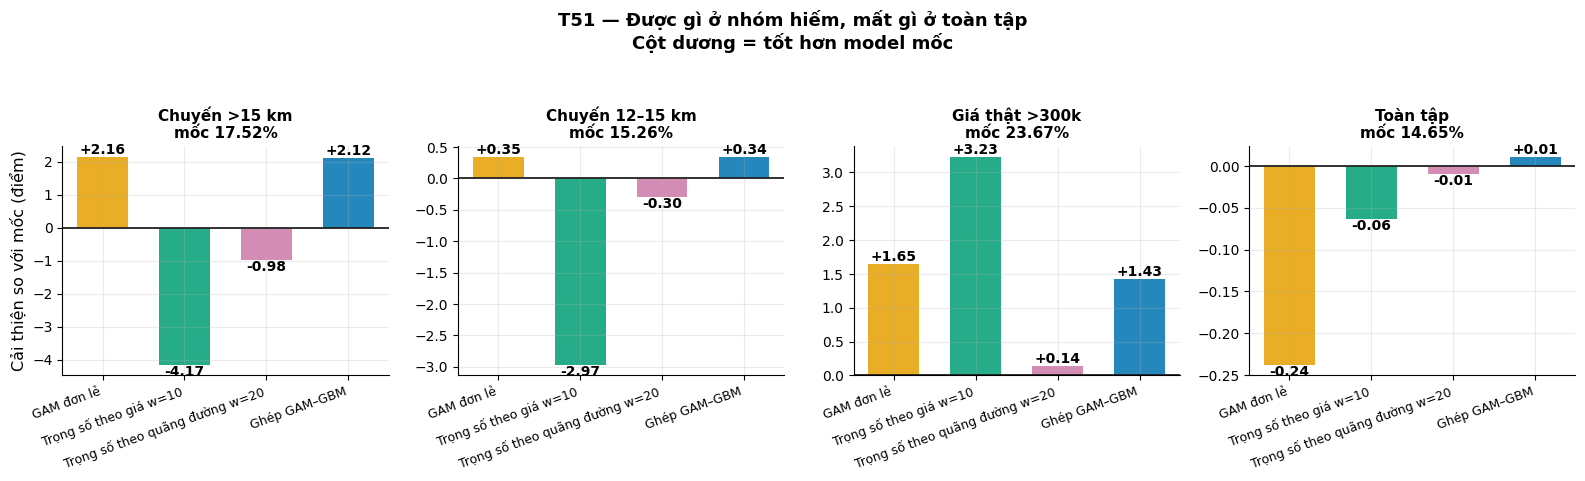

In [7]:
# ═════════ HÌNH T51 — bang D4 duoi dang hinh ═════════
pa = [p for p in D4["Phương án"] if not p.startswith("Hybrid")]
if pa:
    fig, ax = plt.subplots(1, len(NHOM_D4)+1, figsize=(4.0*(len(NHOM_D4)+1), 4.6),
                           sharey=False)
    cot_ve = [x[2] for x in NHOM_D4] + ["Toàn tập"]
    MAU = [ORANGE, GREEN, PURPLE, BLUE]
    for a, c in zip(ax, cot_ve):
        moc = D4[D4["Phương án"].str.startswith("Hybrid")][c].iloc[0]
        for i, p in enumerate(pa):
            v = D4[D4["Phương án"] == p][c].iloc[0]
            a.bar(i, (moc - v)*100, color=MAU[i % len(MAU)], alpha=.85, width=.62)
            a.text(i, (moc - v)*100, f"{(moc-v)*100:+.2f}", ha="center",
                   va="bottom" if v < moc else "top", fontsize=10, fontweight="bold")
        a.axhline(0, color=INK, lw=1.3)
        a.set_xticks(range(len(pa)))
        a.set_xticklabels([p.split("(")[0].strip() for p in pa], rotation=20,
                          ha="right", fontsize=9)
        a.set_title(f"{c}\nmốc {moc:.2%}", fontweight="bold", fontsize=11)
        a.set_ylabel("Cải thiện so với mốc (điểm)" if c == cot_ve[0] else "")
    fig.suptitle("T51 — Được gì ở nhóm hiếm, mất gì ở toàn tập\n"
                 "Cột dương = tốt hơn model mốc",
                 fontweight="bold", fontsize=13, y=1.04)
    fig.tight_layout()
    fig.savefig(HINH / "T51_bang_danh_doi.png")
    plt.show()
else:
    print("Chưa có phương án nào để vẽ — chạy 01 và 03 trước.")

## 3. Phần uncertainty

Tách riêng vì nó không đo bằng MAPE mà bằng coverage và độ rộng.

In [8]:
f = KQ / "C1_so_sanh_hieu_chinh.csv"
if f.exists():
    SS = pd.read_csv(f, index_col=0)
    print(f"Phương án chốt: {C1['phuong_an']}")
    display(SS.style.format({"Coverage": "{:.2%}", "Độ rộng TB": "{:,.0f}đ",
                             "Lệch tối đa (km)": "{:.2f}", "Lệch tối đa (band)": "{:.2f}",
                             "Vượt cận trên": "{:.2%}", "Dưới cận dưới": "{:.2%}",
                             "So độ rộng gốc": "{:+.2%}"}))
else:
    print("Chưa chạy 04_MONDRIAN_QUANG_DUONG.ipynb")

Phương án chốt: Mondrian · quãng đường


,Coverage,Độ rộng TB,Lệch tối đa (km),Lệch tối đa (band),Vượt cận trên,Dưới cận dưới,So độ rộng gốc
Toàn cục,89.81%,"72,637đ",7.42,6.21,7.64%,2.55%,+0.00%
Mondrian · band giá,89.83%,"72,882đ",7.12,6.21,7.63%,2.54%,+0.34%
Mondrian · quãng đường,89.80%,"72,880đ",2.42,4.40,7.65%,2.55%,+0.34%
Mondrian · km × band,89.76%,"72,696đ",6.06,6.21,7.68%,2.56%,+0.08%


## 4. Tóm tắt một trang để dán vào báo cáo

Ba câu, mỗi câu một dòng, có số.

In [9]:
print("═"*74)
print("TUẦN 5 — TÓM TẮT")
print("═"*74)
moc_chung = mape(D.hybrid, D.y)
s15 = D[D.kmb.astype(str) == ">15"]
s3k = D[D.band.astype(str) == ">300k"]
print(f"Mốc (Hybrid GBM): toàn tập {moc_chung:.2%} · >15 km {mape(s15.hybrid, s15.y):.2%} "
      f"· >300k {mape(s3k.hybrid, s3k.y):.2%}")
print()

if DUNG_W:
    print(f"1. TRỌNG SỐ — lưới đầy đủ w∈{W['trong_so']} × {len(W['cach_gan'])} cách gán")
    for pa in [t for _, _, t in PA_W]:
        print(f"   {pa}")
        for _, r in CI[CI["Phương án"] == pa].iterrows():
            print(f"     {r['Nhóm']:<18} {r['Chênh (điểm)']:+.2f} điểm "
                  f"[{r['CI thấp']:+.2f}, {r['CI cao']:+.2f}]  → {r['Kết luận']}")
elif A:
    print(f"1. TRỌNG SỐ — gán theo {A['cach']}, w={A['w']}")
    c = CI[(CI["Phương án"].str.startswith("Trọng số"))]
    for _, r in c.iterrows():
        print(f"     {r['Nhóm']:<18} {r['Chênh (điểm)']:+.2f} điểm "
              f"[{r['CI thấp']:+.2f}, {r['CI cao']:+.2f}]  → {r['Kết luận']}")
    if A.get("nhanh"):
        print("     ⚠ chạy ở CHẾ ĐỘ NHANH — cần chạy lại với NHANH=False trước khi nộp")
else:
    print("1. TRỌNG SỐ — chưa chạy")

print()
if B1:
    print(f"2. GAM — nhóm >15 km: {B1['on_dinh_>15km']}"
          + (f" · điểm giao ~{B1['diem_giao_km']:.0f} km" if B1.get("diem_giao_km") else ""))
    if B2:
        c = CI[CI["Phương án"].str.startswith("Ghép")]
        for _, r in c.iterrows():
            print(f"     ghép: {r['Nhóm']:<18} {r['Chênh (điểm)']:+.2f} điểm "
                  f"[{r['CI thấp']:+.2f}, {r['CI cao']:+.2f}]  → {r['Kết luận']}")
else:
    print("2. GAM — chưa chạy")

print()
if C1:
    print(f"3. UNCERTAINTY — chốt {C1['phuong_an']}")
    print(f"     coverage {C1['coverage']:.2%} · độ rộng {C1['do_rong']:,.0f}đ "
          f"· lệch tối đa giữa nhóm km {C1['lech_toi_da_km']:.2f} điểm")
else:
    print("3. UNCERTAINTY — chưa chạy")
print("═"*74)

══════════════════════════════════════════════════════════════════════════
TUẦN 5 — TÓM TẮT
══════════════════════════════════════════════════════════════════════════
Mốc (Hybrid GBM): toàn tập 14.65% · >15 km 17.52% · >300k 23.67%

1. TRỌNG SỐ — lưới đầy đủ w∈[1, 2, 3, 5, 10, 20] × 3 cách gán
   Trọng số theo giá w=10
     Chuyến >15 km      -4.17 điểm [-5.20, -3.14]  → tệ hơn
     Giá thật >300k     +3.23 điểm [+2.75, +3.68]  → tốt hơn
     Toàn tập           -0.06 điểm [-0.07, -0.06]  → tệ hơn
   Trọng số theo quãng đường w=20
     Chuyến >15 km      -0.98 điểm [-1.46, -0.49]  → tệ hơn
     Giá thật >300k     +0.14 điểm [-0.13, +0.40]  → không phân biệt
     Toàn tập           -0.01 điểm [-0.01, -0.00]  → tệ hơn

2. GAM — nhóm >15 km: ✔ ổn định · GAM thắng · điểm giao ~13 km
     ghép: Chuyến >15 km      +2.12 điểm [+1.47, +2.76]  → tốt hơn
     ghép: Chuyến 12–15 km    +0.34 điểm [+0.19, +0.50]  → tốt hơn
     ghép: Giá thật >300k     +1.43 điểm [+1.05, +1.85]  → tốt hơn
     ghép:

In [10]:
D4.to_csv(KQ / "D4_bang_nop_mentor.csv", index=False)
CI.to_csv(KQ / "D4_khoang_tin_cay.csv", index=False)
print("Đã lưu bảng D4 vào", (KQ / "D4_bang_nop_mentor.csv").resolve())

Đã lưu bảng D4 vào

 C:\Users\Admin\OneDrive\Máy tính\Pricing_Reseach_Vin AI\TP_HCM_data\tuan_5\ket_qua\D4_bang_nop_mentor.csv


## 5. Hai câu mentor yêu cầu trả lời rõ

Điền sau khi chạy xong, mỗi câu một đoạn ngắn có số:

**Câu 1 — Kết quả ở nhóm chuyến dài và giá cao có thực sự tốt hơn không?**
Nhìn cột `Chuyến >15 km` và `Giá thật >300k` trong bảng D4, kèm CI ở bảng dưới. "Thực sự" nghĩa là
khoảng tin cậy loại trừ được 0, không phải chỉ chênh lệch điểm.

**Câu 2 — Kết quả chung bị ảnh hưởng thế nào?**
Nhìn cột `Δ toàn tập`. Âm là tốt lên, dương là xấu đi.

> Nếu không phương án nào vượt được mốc một cách có ý nghĩa thống kê, kết luận đúng là **giữ nguyên
> model hiện tại** và báo cáo rằng hai hướng đã thử đều không cải thiện được. Đó là kết quả hợp lệ.